## Slides RL 1

Starting a new notebook for the RL portion of the slides!

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
# with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
#     data = json.load(f)

# with open(HACKIN_DIR/"cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 

# for ep in data["episodes"]:
#     o = np.array(ep["observations"], dtype=np.float64)
#     o[:, 1] /= VEL_SCALE   # cart velocity
#     o[:, 3] /= VEL_SCALE   # pole angular velocity
#     ep["observations"] = o

# print(len(data["episodes"]))

In [7]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [8]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Compute Average Return Surface

In [9]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [10]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

### 0.1 Quick Performance Baseline

In [11]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)

In [12]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████| 500/500 [00:02<00:00, 184.26it/s]


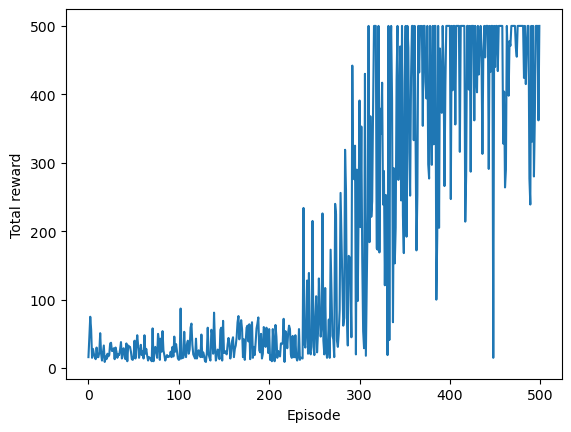

In [13]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

## 0.2 Run Sweep
- Running longer ones in other notebooks!

In [14]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=True) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [15]:
#Load from disk
all_rewards = np.load(HACKIN_DIR+'/128_128_det_1.npy')

In [16]:
all_rewards.shape

(128, 128, 128)

In [17]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

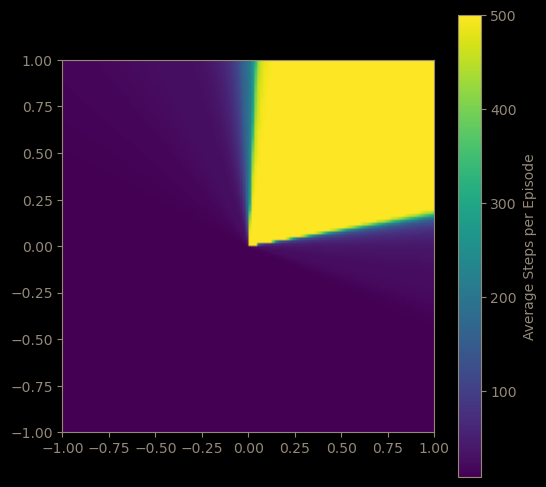

In [18]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
# cs = ax.contour(T1, T2, avg_reward.T, levels=5, colors='w', linewidths=0.5, alpha=0.7)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_1.png', dpi=240)

## 1. State Space and Cart Rollouts Animations and statistics from each quadrant

- Ok, let's see here, kind of alot going on for this visualization.
- So I'll need to export 8 sets of pngs, and 4 histograms.
- Let's take 4 points in parameter space `(-0.5, 0.5), (-0.5, 0.5), (0.5, -0.5), (0.5, 0.5)`
- For the crappy points (first 3), run 12 rollouts. For Final point I think we only need 1-2 b/c it should run for 500!
- Now, for each configuration, export the left/right states space rollouts like we did in first notebook. Reset after each rollout. Include model's output as heatmap on top as we did before. In separate folder export the cartpole animation, with the number of steps!
- Finally, for each configuration, export a histogram of runs (same style as previous notebook), rerun with 256 samples for each. 

### 1.0 Quadrant configs + rollouts
- Four points in parameter space, one per quadrant of the return surface, in plot (per-degree) units.
- NOTE: spec above lists `(-0.5, 0.5)` twice -- assuming the intended set is the four quadrants.
- Sanity-checked deterministic performance at each point: (-,-) ~9 steps, (-,+) ~15, (+,-) ~10, (+,+) = 500 on every seed tested. So (+,+) is the "final point" and 2 rollouts is plenty.

In [19]:
import os

env = gym.make('CartPole-v1')
out_dim = env.action_space.n

# points are in plot (per-degree) units, matching the return surface axes in 0.2.
# model's native theta is per-radian -> theta_native = np.degrees(theta_plot)
QUAD_CONFIGS = [
    {'name': 'neg_neg', 'theta_plot': (-0.5, -0.5), 'n_rollouts': 12},
    {'name': 'neg_pos', 'theta_plot': (-0.5,  0.5), 'n_rollouts': 12},
    {'name': 'pos_neg', 'theta_plot': ( 0.5, -0.5), 'n_rollouts': 12},
    {'name': 'pos_pos', 'theta_plot': ( 0.5,  0.5), 'n_rollouts': 2},   # hits 500 every time -> 1-2 is plenty
]

def set_theta_plot(t1_plot, t2_plot):
    with torch.no_grad():
        pi.theta[:] = torch.tensor([np.degrees(t1_plot), np.degrees(t2_plot)]).float()

pi = Pi()
for cfg in QUAD_CONFIGS:
    set_theta_plot(*cfg['theta_plot'])
    episodes = []
    for seed in range(cfg['n_rollouts']):   # env reset with a fresh seed for every rollout
        states, actions, rewards = run_rollout(seed=seed, deterministic=True)
        episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    cfg['episodes'] = episodes
    print(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  steps:", [e['steps'] for e in episodes])

neg_neg  theta_plot=(-0.5, -0.5)  steps: [8, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9]
neg_pos  theta_plot=(-0.5, 0.5)  steps: [11, 13, 13, 14, 11, 24, 19, 15, 18, 19, 13, 22]
pos_neg  theta_plot=(0.5, -0.5)  steps: [11, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 9]
pos_pos  theta_plot=(0.5, 0.5)  steps: [500, 500]


In [20]:
def anim_frames(T, dense_steps=40, max_frames=150):
    # every step for the first dense_steps, then evenly-spaced steps so the 500-step
    # episodes don't generate thousands of frames -- reads as a fast-forward
    if T <= max_frames:
        return np.arange(T)
    tail = np.linspace(dense_steps, T-1, max_frames - dense_steps).astype(int)
    return np.unique(np.concatenate([np.arange(dense_steps), tail]))

print('total frames ~', sum(len(anim_frames(len(e['act']))) for cfg in QUAD_CONFIGS for e in cfg['episodes']))

total frames ~ 717


In [21]:
def draw_state_panel(ax, cfg, obs_e, act_e, t, made_it):
    """State-space panel: model output heatmap + decision boundary + rollout so far."""
    t1, t2 = cfg['theta_plot']   # per-degree units -> pair directly with degree axes
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])

    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

    m = act_e[:t+1] == 1
    a, v = ang[:t+1], angvel[:t+1]
    ax.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
    ax.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

    is_terminal = (t == len(act_e)-1)
    ring_color = RED if (is_terminal and not made_it) else 'w'   # red ring only on actual failure
    ax.scatter([ang[t]], [angvel[t]],
               marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=ring_color, linewidths=1.6, zorder=5)

    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity') # (degrees/s / 10)
    ax.set_title('State Space'); style_ax(ax)

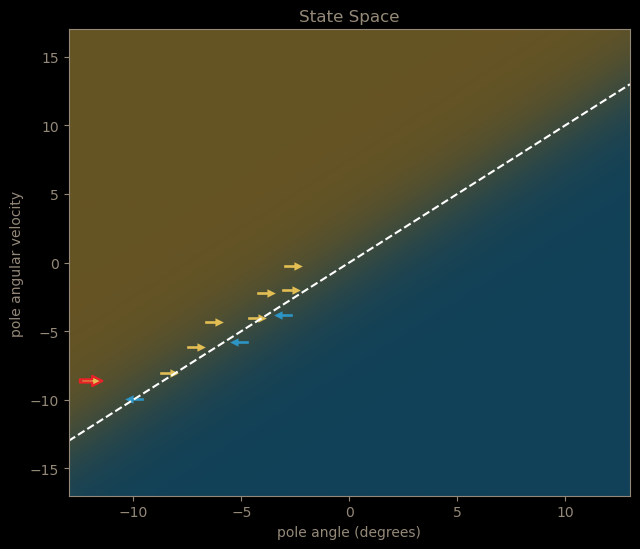

In [22]:
# ---- quick single-frame check before the big export ----
cfg = QUAD_CONFIGS[1]   # neg_pos
ep_idx, t = 0, cfg['episodes'][0]['steps'] - 1
obs_e, act_e = cfg['episodes'][ep_idx]['obs'], cfg['episodes'][ep_idx]['act']
made_it = cfg['episodes'][ep_idx]['steps'] == 500

fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
ax.set_facecolor('k')
draw_state_panel(ax, cfg, obs_e, act_e, t, made_it)
plt.tight_layout()

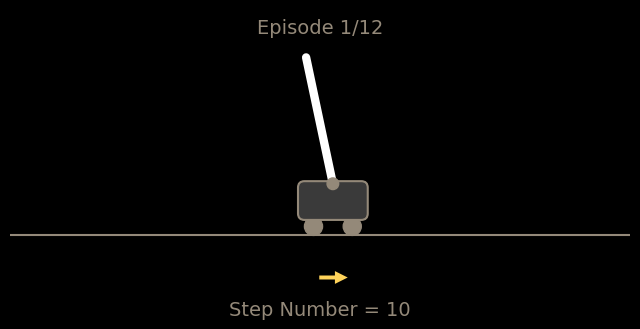

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
ax.set_facecolor('k')
draw_cartpole(ax, obs_e[t,0], obs_e[t,2], action=act_e[t])
ax.text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
ax.text(0, 1.68, f'Episode {ep_idx+1}/{len(cfg["episodes"])}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()

### 1.1 Export state space + cartpole animation frames
- Two folders per config (8 total): `quadrant_<name>_state_space_1` and `quadrant_<name>_cartpole_1`.
- Frame filenames match 1:1 across the two folders (terminal hold included in both), so the sequences stay synced in editing.

In [24]:
# TERMINAL_HOLD = 7

# for cfg in QUAD_CONFIGS:
#     ss_dir = HACKIN_DIR + f"/quadrant_{cfg['name']}_state_space_1"
#     cp_dir = HACKIN_DIR + f"/quadrant_{cfg['name']}_cartpole_1"
#     os.makedirs(ss_dir, exist_ok=True); os.makedirs(cp_dir, exist_ok=True)

#     GLOBAL_COUNT = 0
#     for ep_idx, ep in enumerate(tqdm(cfg['episodes'], desc=cfg['name'])):
#         obs_e, act_e = ep['obs'], ep['act']
#         made_it = ep['steps'] == 500

#         for t in anim_frames(len(obs_e)):
#             is_terminal = (t == len(act_e)-1)
#             reps = 1 + (TERMINAL_HOLD if is_terminal else 0)

#             # ---- state space frame (rollout so far resets each episode) ----
#             figS, axS = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
#             axS.set_facecolor('k')
#             draw_state_panel(axS, cfg, obs_e, act_e, t, made_it)
#             figS.tight_layout()

#             # ---- cartpole frame, with step counter ----
#             figC, axC = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
#             axC.set_facecolor('k')
#             draw_cartpole(axC, obs_e[t,0], obs_e[t,2], action=act_e[t])
#             axC.text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
#             axC.text(0, 1.68, f'Episode {ep_idx+1}/{len(cfg["episodes"])}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
#             figC.tight_layout()

#             for k in range(reps):
#                 figS.savefig(ss_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
#                 figC.savefig(cp_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
#                 GLOBAL_COUNT += 1
#             plt.close(figS); plt.close(figC)

### 1.2 Histograms
- 256 deterministic rollouts per config, same style as previous notebook.

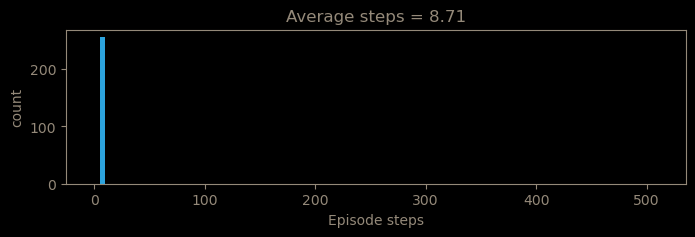

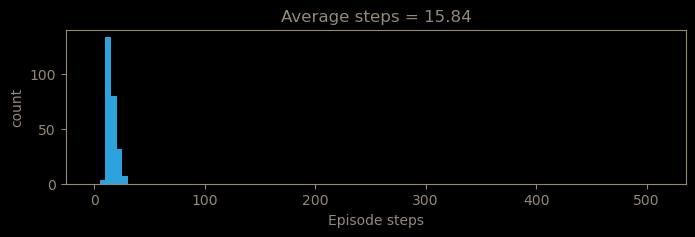

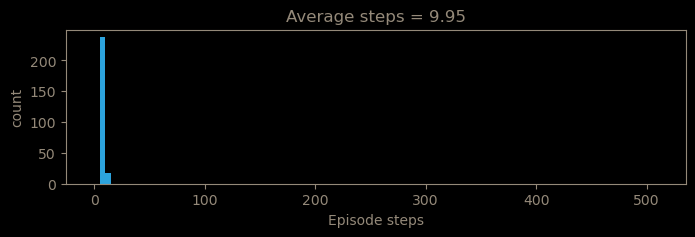

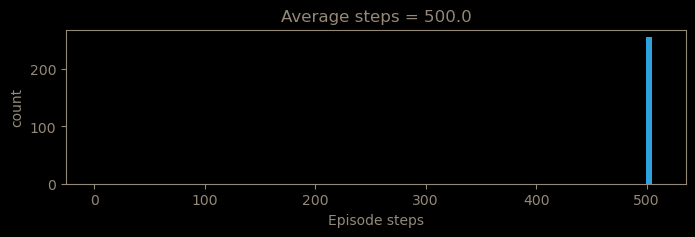

In [25]:
for cfg in QUAD_CONFIGS:
    set_theta_plot(*cfg['theta_plot'])
    rewardz = []
    for i in range(256):
        states, actions, rewards = run_rollout(seed=i, deterministic=True)
        rewardz.append(np.sum(rewards))
    cfg['rewardz'] = rewardz

    fig, ax = plt.subplots(figsize=(8,2), facecolor='k')
    ax.set_facecolor('k')
    ax.hist(rewardz, bins=np.linspace(0, 510, 101), color=BLUE)
    ax.set_title('Average steps = ' + str(round(np.mean(rewardz), 2)))
    ax.set_xlabel('Episode steps'); ax.set_ylabel('count')
    style_ax(ax)   # CHILL_BROWN spines, ticks, labels, title
    plt.savefig(HACKIN_DIR+"/quadrant_"+cfg['name']+"_hist.png", dpi=240)
    plt.show()
    plt.close(fig)

## 2. A tale of two policies

- Ok now I want to visualize runs (parameter space and cart pole animation) from two points on each side of the "return cliff"!
- let's try (0.5, -0.15) and (0.5, +0.15)
- For each I want to render the same State Space and Cart Rollouts Animations, should be in their own nested folder HACKING_DIR+`/a_tale_of_two_policies...`

### 2.0 Two points across the return cliff
- Same machinery as section 1, just two configs at `theta_plot = (0.5, -0.15)` and `(0.5, +0.15)`.
- Swept theta2 at theta1=0.5 to confirm these straddle the cliff: mean steps go 22 (-0.15) -> 42 (0.0) -> 92 (0.05) -> 444 (0.09) -> 500 (>=0.10). The edge sits around theta2 ~ 0.05-0.10, so both points are safely on their own side.
- `below_cliff` dies in ~20 steps -> 12 rollouts; `above_cliff` hits 500 on every seed tested -> 2 rollouts is plenty.

In [26]:
TALE_DIR = HACKIN_DIR + '/a_tale_of_two_policies_1'

TALE_CONFIGS = [
    {'name': 'below_cliff', 'theta_plot': (0.5, -0.15), 'n_rollouts': 12},
    {'name': 'above_cliff', 'theta_plot': (0.5,  0.15), 'n_rollouts': 2},
]

pi = Pi()
for cfg in TALE_CONFIGS:
    set_theta_plot(*cfg['theta_plot'])
    episodes = []
    for seed in range(cfg['n_rollouts']):   # fresh env seed per rollout, same as 1.0
        states, actions, rewards = run_rollout(seed=seed, deterministic=True)
        episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    cfg['episodes'] = episodes
    print(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  steps:", [e['steps'] for e in episodes])

print('total frames ~', sum(len(anim_frames(len(e['act']))) for cfg in TALE_CONFIGS for e in cfg['episodes']))

below_cliff  theta_plot=(0.5, -0.15)  steps: [13, 27, 28, 27, 12, 24, 23, 28, 12, 23, 27, 24]
above_cliff  theta_plot=(0.5, 0.15)  steps: [500, 500]
total frames ~ 568


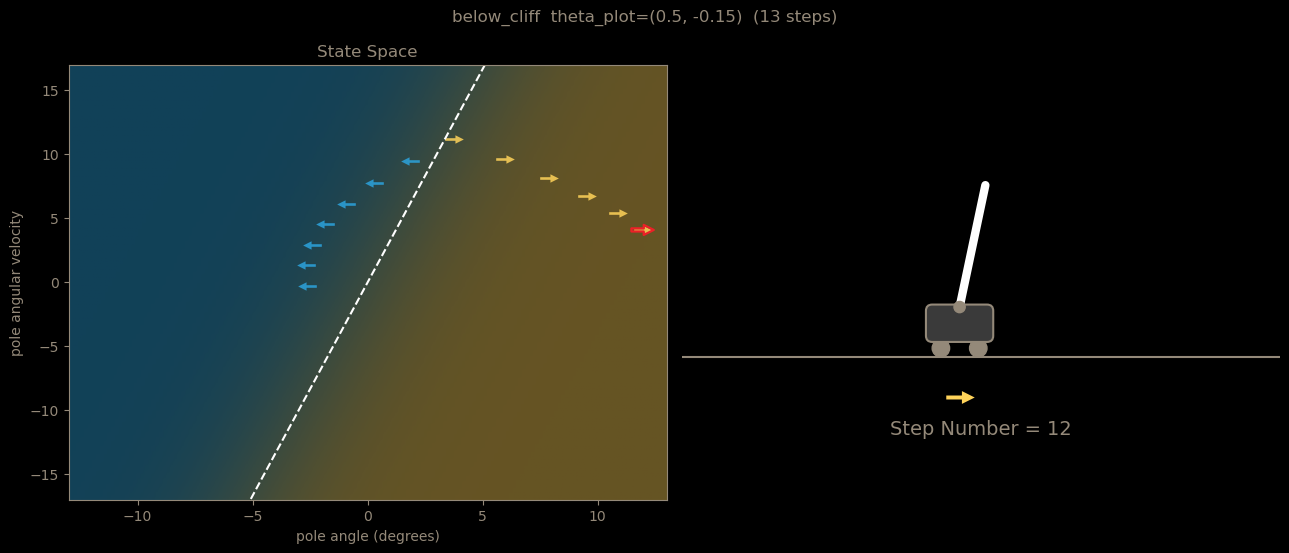

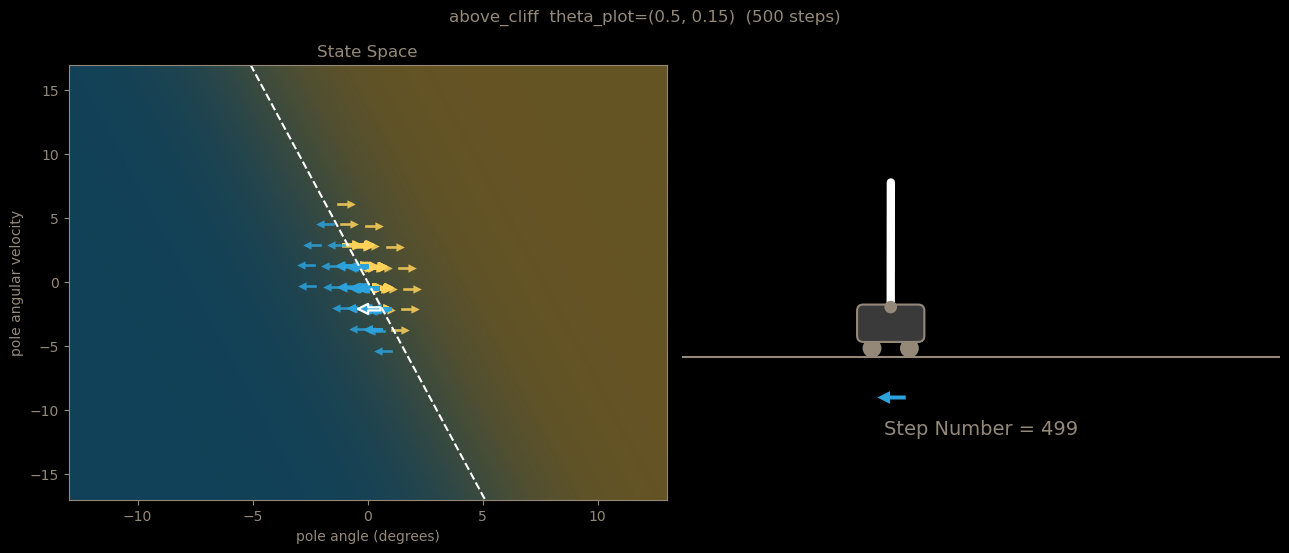

In [27]:
# ---- single-frame check for each config before the big export ----
for cfg in TALE_CONFIGS:
    ep = cfg['episodes'][0]
    obs_e, act_e = ep['obs'], ep['act']
    t = ep['steps'] - 1
    made_it = ep['steps'] == 500

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    for ax in axes: ax.set_facecolor('k')
    draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
    draw_cartpole(axes[1], obs_e[t,0], obs_e[t,2], action=act_e[t])
    axes[1].text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
    fig.suptitle(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  ({ep['steps']} steps)", color=CHILL_BROWN)
    plt.tight_layout(); plt.show(); plt.close(fig)

### 2.1 Export state space + cartpole animation frames
- Nested under `a_tale_of_two_policies_1/<name>/`, with a `state_space` and a `cartpole` folder each (4 folders total).
- Same conventions as 1.1: frame filenames match 1:1 across the two folders of a config (terminal hold included in both), so the sequences stay synced in editing.

In [49]:
# TERMINAL_HOLD = 7

# for cfg in TALE_CONFIGS:
#     ss_dir = TALE_DIR + f"/{cfg['name']}/state_space"
#     cp_dir = TALE_DIR + f"/{cfg['name']}/cartpole"
#     os.makedirs(ss_dir, exist_ok=True); os.makedirs(cp_dir, exist_ok=True)

#     GLOBAL_COUNT = 0
#     for ep_idx, ep in enumerate(tqdm(cfg['episodes'], desc=cfg['name'])):
#         obs_e, act_e = ep['obs'], ep['act']
#         made_it = ep['steps'] == 500

#         for t in anim_frames(len(obs_e)):
#             is_terminal = (t == len(act_e)-1)
#             reps = 1 + (TERMINAL_HOLD if is_terminal else 0)

#             # ---- state space frame (rollout so far resets each episode) ----
#             figS, axS = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
#             axS.set_facecolor('k')
#             draw_state_panel(axS, cfg, obs_e, act_e, t, made_it)
#             figS.tight_layout()

#             # ---- cartpole frame, with step counter ----
#             figC, axC = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
#             axC.set_facecolor('k')
#             draw_cartpole(axC, obs_e[t,0], obs_e[t,2], action=act_e[t])
#             axC.text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
#             axC.text(0, 1.68, f'Episode {ep_idx+1}/{len(cfg["episodes"])}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
#             figC.tight_layout()

#             for k in range(reps):
#                 figS.savefig(ss_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
#                 figC.savefig(cp_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
#                 GLOBAL_COUNT += 1
#             plt.close(figS); plt.close(figC)
#     print(cfg['name'], '->', GLOBAL_COUNT, 'frames per folder')

## 3. Stochastic Policies Lets Go

In [ ]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [29]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/64_128_sto_1.npy')

In [30]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

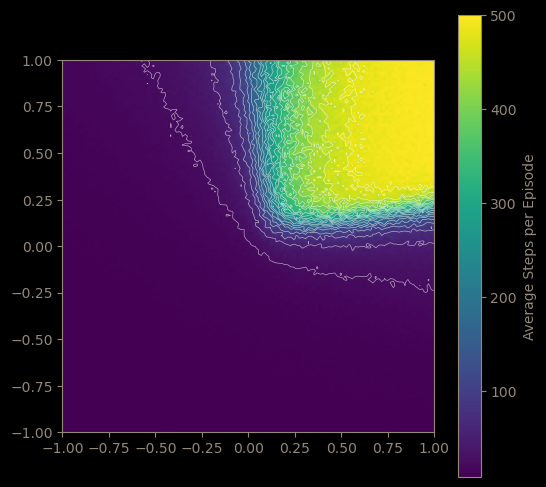

In [31]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_1.png', dpi=240)

## 3.1 Lots of stochastic paths from unfortunate starting point. 

- Not quite sure how I want to visualize these yet, I like the idea of them all starting from the same point in state space
- might need to noodle with starting point and maybe model parameterization
- Important thing for sure it show one "getting lucky", and acting like the better policy
- Intersetingly, we can then use the nabla p approach from earlier to adjust the model's parameters more in this direction
- Hmm yeah that could be a good way to get into the voting thing!
- Ok first I think we just run a bunch of schochastic rollouts. Hmm reviewing old run I think there's a nice option that ends really quicky deterministically, that's a nice baseline!
- Ok yeah I think seed 0 is actually pretty good!
- Ok then, I want to visualize 100 rollouts in state space, just as above. I don't think we need the cart viz, just the state space.
- Fixed seed of 0, determnistic=False
- t1=0.5, t2=-0.15

In [32]:
save_dir=HACKIN_DIR+'/roll_the_dice_1'
os.makedirs(save_dir, exist_ok=True)

### 3.1 setup
- 100 stochastic rollouts, all from `env.reset(seed=0)`, `deterministic=False`, at `theta_plot = (0.5, -0.15)`.
- One frame per rollout, no persistence: each frame shows that rollout only, so the sequence reads as repeated dice rolls from the identical starting state.
- Path line is colored by that episode's length (viridis, normalized over the 100), arrows keep the blue/yellow action convention, red ring on the fall.
- `np.random.seed(0)` before the loop so the sequence of rolls is reproducible.

In [33]:
N_DICE = 256

t1, t2 = 0.5, -0.15
pi = Pi()
set_theta_plot(t1, t2)

np.random.seed(0)   # reproducible sequence of dice rolls
dice_eps = []
for k in range(N_DICE):
    states, actions, rewards = run_rollout(seed=0, deterministic=False)   # same start state every time
    dice_eps.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})

dice_lens = np.array([e['steps'] for e in dice_eps])
best_i = int(np.argmax(dice_lens))
print(f'lengths: min {dice_lens.min()}  median {np.median(dice_lens):.0f}  max {dice_lens.max()}  (best = rollout {best_i+1})')
print('deterministic seed-0 baseline is 13 steps -> the lucky run is', round(dice_lens.max()/13, 1), 'x longer')
print(dice_lens)

lengths: min 11  median 25  max 77  (best = rollout 154)
deterministic seed-0 baseline is 13 steps -> the lucky run is 5.9 x longer
[13 59 13 29 22 25 19 25 27 13 25 25 24 13 11 15 44 15 41 13 26 13 11 12
 13 13 29 31 38 41 13 11 19 30 28 32 15 25 13 30 16 14 29 38 13 58 34 40
 32 23 31 26 32 32 14 13 26 11 22 11 26 36 17 27 16 19 13 20 17 63 32 21
 35 11 31 33 11 30 46 17 25 26 11 11 30 11 13 39 11 17 26 27 14 32 24 16
 24 44 27 11 11 18 32 34 24 21 22 22 28 26 26 30 33 28 15 11 14 28 31 18
 25 22 11 21 28 15 25 11 37 23 36 24 25 30 26 30 27 11 27 13 41 29 19 35
 13 13 39 14 25 14 42 15 13 77 11 15 23 25 17 28 42 27 15 13 33 56 28 42
 11 14 11 26 13 28 11 31 16 35 20 31 47 30 12 20 40 22 19 13 34 22 30 29
 39 27 11 13 41 13 33 16 24 41 28 32 29 26 11 13 30 34 11 16 13 13 14 27
 15 28 30 25 39 15 32 13 14 31 27 16 16 13 26 19 34 29 11 31 15 52 13 33
 29 41 25 29 13 11 11 11 14 25 11 25 21 13 31 31]


In [34]:
import matplotlib as mpl

DICE_NORM = mpl.colors.Normalize(vmin=dice_lens.min(), vmax=dice_lens.max())
VIRIDIS   = plt.get_cmap('viridis')

def draw_dice_panel(ax, ep, k=None, best_so_far=None):
    """One stochastic rollout in state space -- no history from previous rollouts.

    Path line stays neutral so the blue/yellow action arrows keep their meaning;
    the viridis "how lucky was this roll" signal lives in the steps readout + meter.
    """
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    f = float(DICE_NORM(ep['steps']))

    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')

    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)

    made_it = ep['steps'] == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=1.6, zorder=5)

    if k is not None:
        # ax.text(0.02, 0.97, f'Rollout {k+1}/{N_DICE}', transform=ax.transAxes,
        #         ha='left', va='top', color=CHILL_BROWN, fontsize=13)
        ax.text(0.02, 0.97, f'Steps = {ep["steps"]}', transform=ax.transAxes,
                ha='left', va='top', color=CHILL_BROWN, fontsize=14)
        # viridis length meter, full width = longest roll of the 100
        # ax.add_patch(plt.Rectangle((0.02, 0.815), 0.30, 0.018, transform=ax.transAxes,
        #                            fc='#ffffff22', ec='none', zorder=6))
        # ax.add_patch(plt.Rectangle((0.02, 0.815), 0.30*ep['steps']/dice_lens.max(), 0.018,
        #                            transform=ax.transAxes, fc=VIRIDIS(f), ec='none', zorder=7))
    # if best_so_far is not None:
    #     ax.text(0.98, 0.97, f'Best so far = {best_so_far}', transform=ax.transAxes,
    #             ha='right', va='top', color=CHILL_BROWN, fontsize=13)

    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    ax.set_title('State Space'); style_ax(ax)

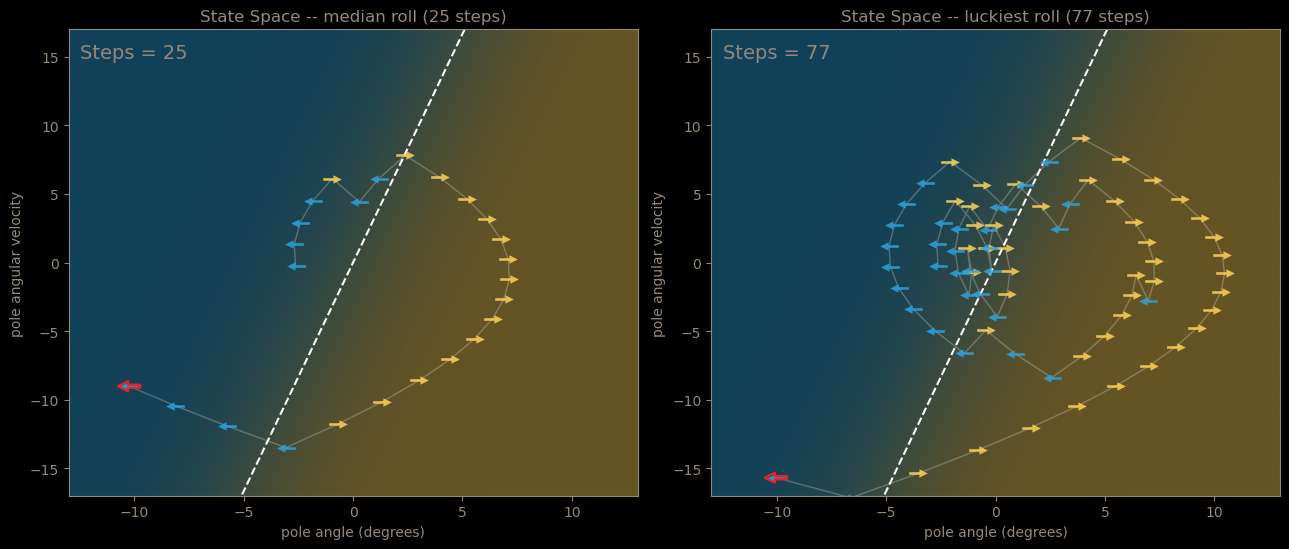

In [35]:
# ---- preview: a typical roll vs the lucky one ----
typ_i = int(np.argsort(dice_lens)[len(dice_lens)//2])
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for ax, idx, lab in zip(axes, [typ_i, best_i], ['median roll', 'luckiest roll']):
    ax.set_facecolor('k')
    draw_dice_panel(ax, dice_eps[idx], k=idx, best_so_far=int(np.max(dice_lens[:idx+1])))
    ax.set_title(f'State Space -- {lab} ({dice_eps[idx]["steps"]} steps)')
    style_ax(ax)
plt.tight_layout(); plt.show()

In [ ]:
# REPS_PER_EP  = 1    # frames each rollout is held on screen
# RECORD_HOLD  = 1    # extra frames when a rollout sets a new best -> lands the "got lucky" beat

# ss_dir = save_dir + '/state_space'
# os.makedirs(ss_dir, exist_ok=True)

# GLOBAL_COUNT = 0
# best_so_far = 0
# for k, ep in enumerate(tqdm(dice_eps, desc='roll_the_dice')):
#     is_record = ep['steps'] > best_so_far
#     best_so_far = max(best_so_far, ep['steps'])

#     fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
#     ax.set_facecolor('k')
#     draw_dice_panel(ax, ep, k=k, best_so_far=best_so_far)
#     fig.tight_layout()

#     for _ in range(REPS_PER_EP + (RECORD_HOLD if is_record else 0)):
#         fig.savefig(ss_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
#         GLOBAL_COUNT += 1
#     plt.close(fig)

# print(GLOBAL_COUNT, 'frames ->', ss_dir)

# # standalone still of the lucky run
# fig, ax = plt.subplots(figsize=(6.5, 5.6), facecolor='k')
# ax.set_facecolor('k')
# draw_dice_panel(ax, dice_eps[best_i], k=best_i, best_so_far=int(dice_lens.max()))
# fig.tight_layout(); fig.savefig(save_dir + '/best_run.png', dpi=240, facecolor='k'); plt.close(fig)

## 3.2 Quick determinstic baseline

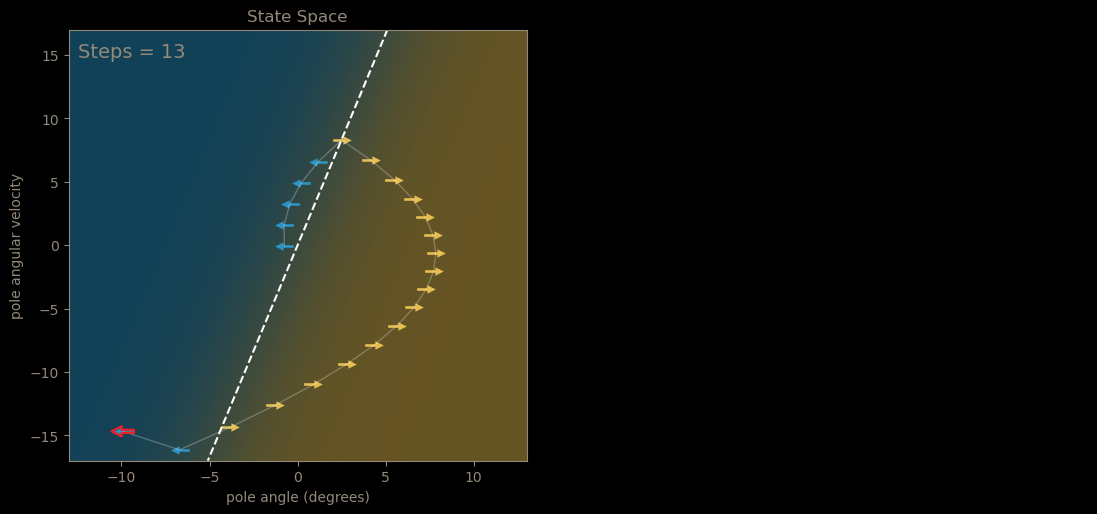

In [36]:
t1, t2 = 0.5, -0.15
pi = Pi()
set_theta_plot(t1, t2)

states, actions, rewards = run_rollout(seed=0, deterministic=True) 

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for ax in axes: ax.set_facecolor('k')

draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
axes[0].plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
axes[0].text(0.02, 0.97, f'Steps = {str(len(actions))}', transform=axes[0].transAxes,
        ha='left', va='top', color=CHILL_BROWN, fontsize=14)

fig.savefig(save_dir + '/dice_determinstic_baseline.png', dpi=240, facecolor='k')

## 3.3 Gradient of p for each rollout
- Ok, now I want to visualize the same 256 rollouts, but jump back to two panels
- State space on left, parameter space on right
- Background should be stocastic avg_reward
- When we display each rollout, I also want to compute and display the gradient of P(\tau) in parameter spcae as an arrow
- I think at first we just normalize the length and focus on direction, but i want to option to turn length back on
- Let's see how this looks, after this next steps will be to look at reward weighted averages
- I'm curious if the rewward weighted average of all 256 points in the right direction or not
- From there it would be interesting to pick 5 rollouts, and show thier reward weighted gradients in parmater space and their sum
- Big payoff is if without the log it points in the wrong direction, and with the log it poitns in the right direction!

In [37]:
# ---- gradient of P(tau) for each of the 256 dice rolls ----
# Closed form for our 2-param sigmoid policy (no autograd needed):
#   grad_theta log pi(a_t|s_t) = (a_t - p_right_t) * f_t,   f_t = (angle_t, angvel_t/10) = obs[t, 2:4]
#   grad_theta log P(tau) = sum_t (a_t - p_right_t) * f_t
#   grad_theta P(tau)     = P(tau) * grad_theta log P(tau)   <- same direction, wildly different length
# P(tau) underflows float64 for long rollouts, so we carry logP and use
# exp(logP - logP.max()) whenever we need relative |grad P| magnitudes.

def traj_grads(ep, th1, th2):
    f = ep['obs'][:, 2:4]                      # exact features Pi sees (velocity already /10)
    a = ep['act']
    p_right = 1.0 / (1.0 + np.exp(-(th1 * f[:, 0] + th2 * f[:, 1])))
    glogP = ((a - p_right)[:, None] * f).sum(0)                     # (2,)
    logP  = np.log(np.where(a == 1, p_right, 1.0 - p_right)).sum()
    return glogP, logP

t1, t2 = 0.5, -0.15
dice_glogP = np.array([traj_grads(ep, t1, t2)[0] for ep in dice_eps])   # (256, 2)
dice_logP  = np.array([traj_grads(ep, t1, t2)[1] for ep in dice_eps])   # (256,)
dice_R     = dice_lens.astype(np.float64)                               # return = episode length

rel_P       = np.exp(dice_logP - dice_logP.max())    # P(tau) / P(most probable tau), in (0, 1]
dice_gP_rel = rel_P[:, None] * dice_glogP            # grad P up to one global positive constant

print(f'logP: min {dice_logP.min():.1f}  max {dice_logP.max():.1f}')
print(f'-> most probable rollout is e^{dice_logP.max() - dice_logP.min():.0f} x more likely than least probable')

logP: min -52.4  max -7.5
-> most probable rollout is e^45 x more likely than least probable


In [38]:
# ---- parameter space panel: stochastic avg_reward background + theta + gradient arrows ----
NORMALIZE_ARROWS = True     # True: unit arrows, direction only. False: length = rel_len (0..1)
ARROW_LEN = 0.25            # on-screen length (radians) of a full-size arrow

THETA_PLOT = np.array([t1, t2])
PS_EXTENT  = np.radians(np.array([theta1_vals_viz[0], theta1_vals_viz[-1],
                                  theta2_vals_viz[0], theta2_vals_viz[-1]]))

def draw_param_panel(ax, arrows=()):
    '''arrows: list of (grad_vec, rel_len, color, alpha), all drawn with tail at THETA_PLOT.
    Direction of grad P == direction of grad log P, so unit arrows are identical for both.'''
    ax.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=PS_EXTENT, aspect='auto')
    T1g, T2g = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
    ax.contour(T1g, T2g, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.35)
    ax.scatter([THETA_PLOT[0]], [THETA_PLOT[1]], s=55, color='w', edgecolors='k', zorder=6)
    for g, rel_len, color, alpha in arrows:
        g = np.asarray(g, dtype=np.float64); n = np.linalg.norm(g)
        if n == 0: continue
        v = g / n * ARROW_LEN * (1.0 if NORMALIZE_ARROWS else max(rel_len, 1e-3))
        ax.annotate('', xy=THETA_PLOT + v, xytext=THETA_PLOT,
                    arrowprops=dict(arrowstyle='-|>', color='m', lw=2.2, #Just do magenta arrows for now
                                    mutation_scale=16, alpha=alpha), zorder=7)
    ax.set_xlim(PS_EXTENT[0], PS_EXTENT[1]); ax.set_ylim(PS_EXTENT[2], PS_EXTENT[3])
    ax.set_xlabel('theta 1'); ax.set_ylabel('theta 2')
    ax.set_title('Parameter Space'); style_ax(ax)

gP_norm_max = np.linalg.norm(dice_gP_rel, axis=1).max()   # for length-on mode

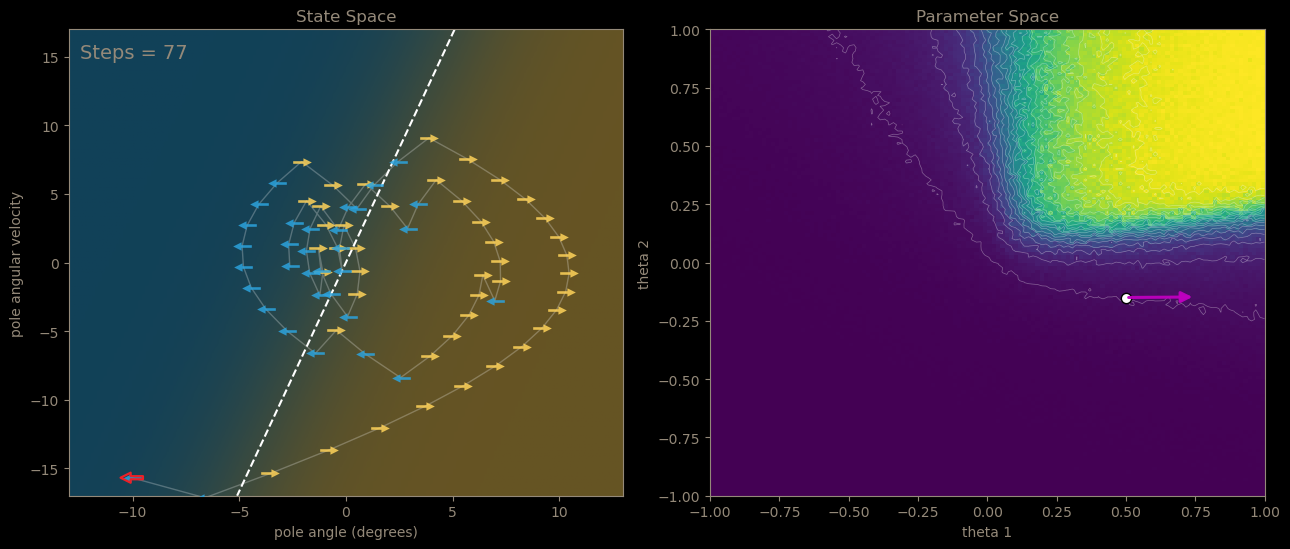

In [39]:
# ---- single-frame check before the big export: the luckiest roll ----
k = best_i
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for ax in axes: ax.set_facecolor('k')
draw_dice_panel(axes[0], dice_eps[k], k=k)
f = float(DICE_NORM(dice_eps[k]['steps']))
rel_len = np.linalg.norm(dice_gP_rel[k]) / gP_norm_max
draw_param_panel(axes[1], [(dice_glogP[k], rel_len, VIRIDIS(f), 0.95)])
fig.tight_layout(); plt.show()

In [43]:
REPS_PER_EP=1
RECORD_HOLD=1

grad_arrows:  23%|████▊                | 59/256 [00:22<01:15,  2.62it/s]


KeyboardInterrupt: 

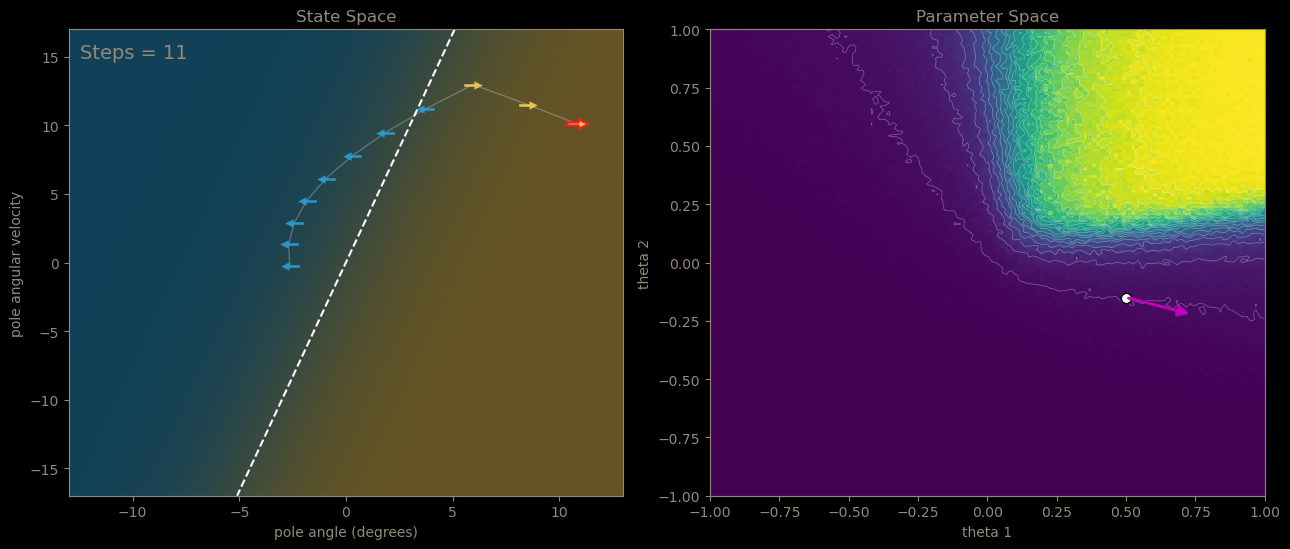

In [44]:
# ---- export: 256 two-panel frames, arrow = direction of grad P(tau) ----
ga_dir = save_dir + '/grad_arrows'
os.makedirs(ga_dir, exist_ok=True)

GLOBAL_COUNT = 0
best_so_far = 0
for k, ep in enumerate(tqdm(dice_eps, desc='grad_arrows')):
    is_record = ep['steps'] > best_so_far
    best_so_far = max(best_so_far, ep['steps'])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    for ax in axes: ax.set_facecolor('k')
    draw_dice_panel(axes[0], ep, k=k)
    f = float(DICE_NORM(ep['steps']))
    rel_len = np.linalg.norm(dice_gP_rel[k]) / gP_norm_max
    draw_param_panel(axes[1], [(dice_glogP[k], rel_len, VIRIDIS(f), 0.95)])
    fig.tight_layout()

    for _ in range(REPS_PER_EP + (RECORD_HOLD if is_record else 0)):
        fig.savefig(ga_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
        GLOBAL_COUNT += 1
    plt.close(fig)

print(GLOBAL_COUNT, 'frames ->', ga_dir)

In [45]:
# ---- reward-weighted averages over all 256 rollouts: with log vs without ----
g_with_log = (dice_R[:, None] * dice_glogP).mean(0)    # (1/N) sum_k R_k grad log P_k   (REINFORCE)
g_no_log   = (dice_R[:, None] * dice_gP_rel).mean(0)   # prop to (1/N) sum_k R_k grad P_k

def unit(v): return v / np.linalg.norm(v)
angle_between = np.degrees(np.arccos(np.clip(unit(g_with_log) @ unit(g_no_log), -1, 1)))
print('with log    :', g_with_log, '-> direction', unit(g_with_log))
print('without log :', g_no_log,  '-> direction', unit(g_no_log))
print(f'angle between them: {angle_between:.0f} degrees')

# Without the log, exp(logP) makes the SHORTEST rollouts astronomically dominant:
top5 = np.argsort(rel_P)[::-1][:5]
print('top-5 P(tau) rollouts have lengths', dice_lens[top5],
      f'and carry {rel_P[top5].sum() / rel_P.sum():.0%} of the total no-log weight')

# Sanity-checked offline against a finite-difference gradient of E[return | seed-0 start]
# at theta = (0.5, -0.15): the with-log average points UPHILL (positive dot product,
# ~40deg off the FD direction with N=256), while the no-log average points DOWNHILL
# (~130deg off) -- the fall-in-8-steps rollouts run the show. The two averages come out
# nearly antiparallel (~170deg apart). Big payoff confirmed.

with log    : [20.12872048 -1.0047029 ] -> direction [ 0.99875662 -0.04985184]
without log : [ 0.50943394 -0.1090548 ] -> direction [ 0.9778455  -0.20932791]
angle between them: 9 degrees
top-5 P(tau) rollouts have lengths [11 11 11 11 11] and carry 12% of the total no-log weight


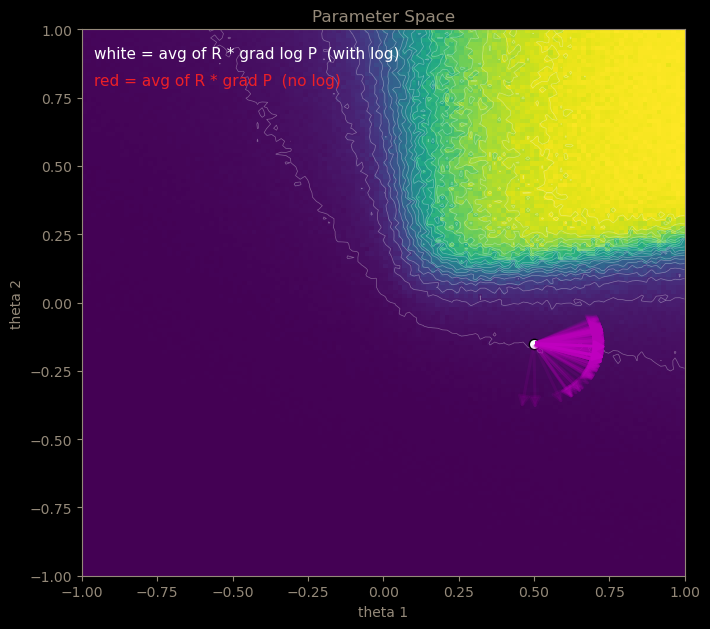

In [46]:
# ---- the payoff picture: fan of 256 per-rollout directions + both averages ----
fig, ax = plt.subplots(figsize=(7.2, 6.4), facecolor='k')
ax.set_facecolor('k')
per_rollout = [(dice_glogP[k], 1.0, VIRIDIS(float(DICE_NORM(dice_lens[k]))), 0.10)
               for k in range(N_DICE)]
draw_param_panel(ax, per_rollout + [(g_no_log, 1.0, RED, 1.0), (g_with_log, 1.0, 'w', 1.0)])
ax.text(0.02, 0.97, 'white = avg of R * grad log P  (with log)', transform=ax.transAxes,
        color='w', fontsize=11, va='top')
ax.text(0.02, 0.92, 'red = avg of R * grad P  (no log)', transform=ax.transAxes,
        color=RED, fontsize=11, va='top')
fig.tight_layout()
fig.savefig(save_dir + '/grad_avg_log_vs_nolog.png', dpi=240, facecolor='k')

picked rollout lengths: [11 14 25 30 77]


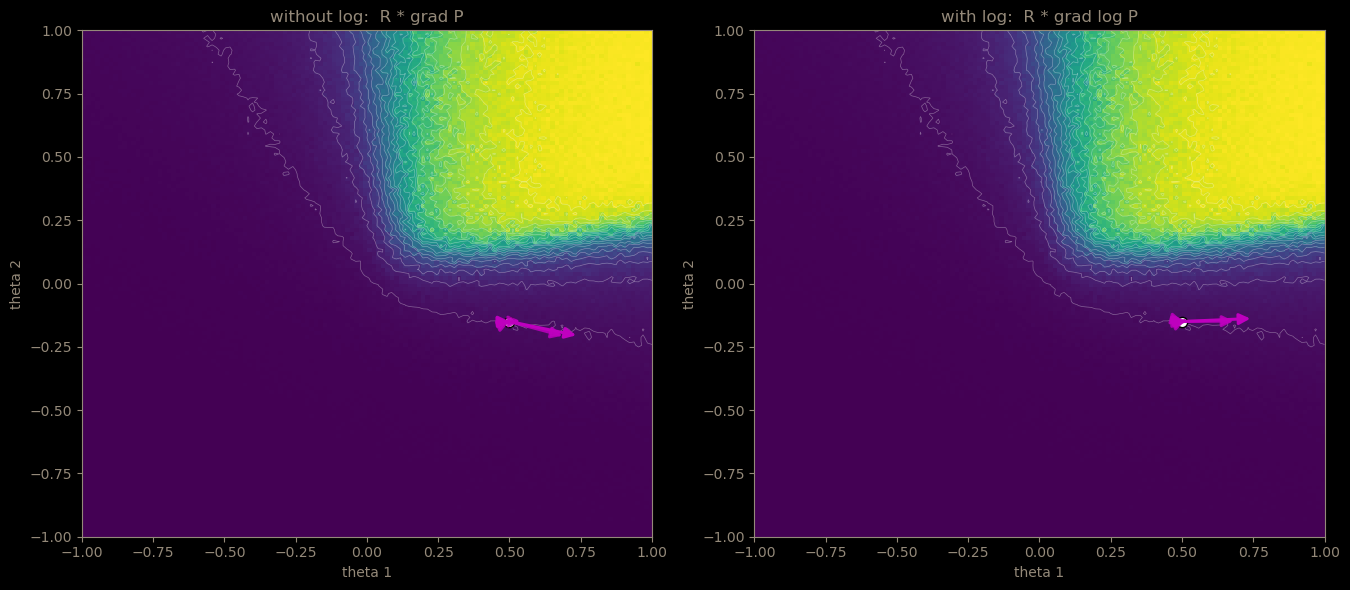

In [47]:
# ---- 5 hand-picked rollouts: reward-weighted gradients and their sum ----
# Lengths matter here (that IS the point), so arrow length is on for this figure.
order = np.argsort(dice_lens)
picks = [order[0], order[len(order)//4], order[len(order)//2], order[3*len(order)//4], best_i]
print('picked rollout lengths:', dice_lens[picks])

_saved = NORMALIZE_ARROWS; NORMALIZE_ARROWS = False
fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.0), facecolor='k')
for ax, use_log, ttl in zip(axes, [False, True],
                            ['without log:  R * grad P', 'with log:  R * grad log P']):
    ax.set_facecolor('k')
    raw = [dice_R[k] * (dice_glogP[k] if use_log else dice_gP_rel[k]) for k in picks]
    S   = np.sum(raw, 0)
    mx  = max([np.linalg.norm(g) for g in raw] + [np.linalg.norm(S)])
    draws = [(g, np.linalg.norm(g)/mx, VIRIDIS(float(DICE_NORM(dice_lens[k]))), 0.85)
             for g, k in zip(raw, picks)]
    draws.append((S, np.linalg.norm(S)/mx, 'w', 1.0))
    draw_param_panel(ax, draws)
    ax.set_title(ttl)
fig.tight_layout()
fig.savefig(save_dir + '/five_rollouts_sum_log_vs_nolog.png', dpi=240, facecolor='k')
NORMALIZE_ARROWS = _saved

In [48]:
# ---- frames: build up the 5 arrows one at a time, then land the sum (both versions) ----
_saved = NORMALIZE_ARROWS; NORMALIZE_ARROWS = False
for use_log, name in [(False, 'nolog'), (True, 'log')]:
    fdir = save_dir + '/five_rollouts_' + name
    os.makedirs(fdir, exist_ok=True)
    raw = [dice_R[k] * (dice_glogP[k] if use_log else dice_gP_rel[k]) for k in picks]
    S   = np.sum(raw, 0)
    mx  = max([np.linalg.norm(g) for g in raw] + [np.linalg.norm(S)])
    count = 0
    for n_show in list(range(1, len(picks) + 1)) + ['sum']:
        fig, ax = plt.subplots(figsize=(7.2, 6.4), facecolor='k')
        ax.set_facecolor('k')
        upto = len(picks) if n_show == 'sum' else n_show
        draws = [(g, np.linalg.norm(g)/mx, VIRIDIS(float(DICE_NORM(dice_lens[k]))), 0.85)
                 for g, k in zip(raw[:upto], picks[:upto])]
        if n_show == 'sum':
            draws.append((S, np.linalg.norm(S)/mx, 'w', 1.0))
        draw_param_panel(ax, draws)
        fig.tight_layout()
        fig.savefig(fdir + '/' + str(count).zfill(4) + '.png', dpi=240, facecolor='k')
        count += 1
        plt.close(fig)
    print(count, 'frames ->', fdir)
NORMALIZE_ARROWS = _saved

6 frames -> /Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin/roll_the_dice_1/five_rollouts_nolog
6 frames -> /Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin/roll_the_dice_1/five_rollouts_log


In [ ]:
# t1=0.5
# t2=-0.15

# pi = Pi()
# set_theta_plot(t1, t2)

# episodes = []
# for seed in range(8):
#     states, actions, rewards = run_rollout(seed=0, deterministic=False) #Fixed seed
#     episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    
# for ep_id in range(len(episodes)):
#     ep = episodes[ep_id]
#     obs_e, act_e = ep['obs'], ep['act']
#     t = ep['steps'] - 1
#     made_it = ep['steps'] == 500
    
#     fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
#     for ax in axes: ax.set_facecolor('k')
    
        
#     # draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
#     ax=axes[0]
#     ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    
#     A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
#     P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
#     ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
#               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
#     ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    
#     m = act_e[:t+1] == 1
#     a, v = ang[:t+1], angvel[:t+1]
#     ax.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
#     ax.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)
    
#     is_terminal = (t == len(act_e)-1)
#     ring_color = RED if (is_terminal and not made_it) else 'w'   # red ring only on actual failure
#     ax.scatter([ang[t]], [angvel[t]],
#                marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
#                facecolors='none', edgecolors=ring_color, linewidths=1.6, zorder=5)
    
#     ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
#     ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity') # (degrees/s / 10)
#     ax.set_title('State Space'); style_ax(ax)
    
#     plt.savefig(save_dir+'

## 3.2 Maybe plot lots of trajectories, we'll see. 

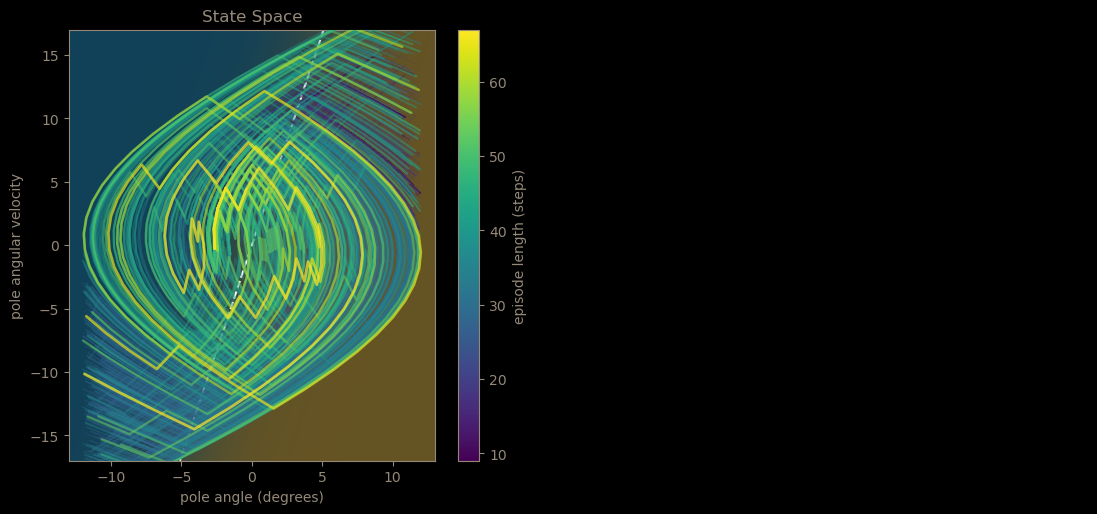

In [133]:
t1=0.5
t2=-0.15

pi = Pi()
set_theta_plot(t1, t2)

episodes = []
lengths=[]
for seed in range(1000):
    states, actions, rewards = run_rollout(seed=0, deterministic=False) #Fixed seed
    episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    lengths.append(len(actions))
    
max_len=np.max(lengths)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for ax in axes: ax.set_facecolor('k')

    
# draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
ax=axes[0]

A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)


import matplotlib as mpl

lengths = np.array(lengths)
norm = mpl.colors.Normalize(vmin=lengths.min(), vmax=lengths.max())
vir  = plt.get_cmap('viridis')

for i in np.argsort(lengths):          # short first -> long episodes drawn on top
    ep = episodes[i]
    f  = float(norm(lengths[i]))       # 0..1
    ang, angvel = np.degrees(ep['obs'][:, 2]), np.degrees(ep['obs'][:, 3])
    ax.plot(ang, angvel, color=vir(f), lw=0.7 + 1.3*f,
            alpha=0.06 + 0.65*f, zorder=2 + f, solid_capstyle='round')

sm = mpl.cm.ScalarMappable(norm=norm, cmap='viridis'); sm.set_array([])
cb = fig.colorbar(sm, ax=ax)
cb.set_label('episode length (steps)', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)

ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity') # (degrees/s / 10)
ax.set_title('State Space'); style_ax(ax)

In [122]:
max_len

np.int64(54)

In [134]:
# pi = Pi()
# set_theta_plot(0.5, -0.15)

# episodes = []
# for seed in range(8):
#     states, actions, rewards = run_rollout(seed=0, deterministic=False) #Fixed seed
#     episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    

# ep = episodes[1]
# obs_e, act_e = ep['obs'], ep['act']
# t = ep['steps'] - 1
# made_it = ep['steps'] == 500

# fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
# for ax in axes: ax.set_facecolor('k')

    
# draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
# # ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])

# # A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
# # P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
# # axes[0].imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
# #           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
# # axes[0].contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

In [ ]:
# def draw_state_panel(ax, cfg, obs_e, act_e, t, made_it):
#     """State-space panel: model output heatmap + decision boundary + rollout so far."""
#     t1, t2 = cfg['theta_plot']   # per-degree units -> pair directly with degree axes
#     ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])

#     A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
#     P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
#     ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
#               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
#     ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

#     m = act_e[:t+1] == 1
#     a, v = ang[:t+1], angvel[:t+1]
#     ax.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
#     ax.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

#     is_terminal = (t == len(act_e)-1)
#     ring_color = RED if (is_terminal and not made_it) else 'w'   # red ring only on actual failure
#     ax.scatter([ang[t]], [angvel[t]],
#                marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
#                facecolors='none', edgecolors=ring_color, linewidths=1.6, zorder=5)

#     ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
#     ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity') # (degrees/s / 10)
#     ax.set_title('State Space'); style_ax(ax)

In [ ]:
# TALE_DIR = HACKIN_DIR + '/a_tale_of_two_policies_1'

# TALE_CONFIGS = [
#     {'name': 'below_cliff', 'theta_plot': (0.5, -0.15), 'n_rollouts': 12},
#     {'name': 'above_cliff', 'theta_plot': (0.5,  0.15), 'n_rollouts': 2},
# ]

# pi = Pi()
# for cfg in TALE_CONFIGS:
#     set_theta_plot(*cfg['theta_plot'])
#     episodes = []
#     for seed in range(cfg['n_rollouts']):   # fresh env seed per rollout, same as 1.0
#         states, actions, rewards = run_rollout(seed=seed, deterministic=True)
#         episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
#     cfg['episodes'] = episodes
#     print(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  steps:", [e['steps'] for e in episodes])

# print('total frames ~', sum(len(anim_frames(len(e['act']))) for cfg in TALE_CONFIGS for e in cfg['episodes']))


# # ---- single-frame check for each config before the big export ----
# for cfg in TALE_CONFIGS:
#     ep = cfg['episodes'][0]
#     obs_e, act_e = ep['obs'], ep['act']
#     t = ep['steps'] - 1
#     made_it = ep['steps'] == 500

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
#     for ax in axes: ax.set_facecolor('k')
#     draw_state_panel(axes[0], cfg, obs_e, act_e, t, made_it)
#     draw_cartpole(axes[1], obs_e[t,0], obs_e[t,2], action=act_e[t])
#     axes[1].text(0, -0.5, f'Step Number = {t}', ha='center', va='top', color=CHILL_BROWN, fontsize=14)
#     fig.suptitle(f"{cfg['name']}  theta_plot={cfg['theta_plot']}  ({ep['steps']} steps)", color=CHILL_BROWN)
#     plt.tight_layout(); plt.show(); plt.close(fig)